# Journalist_Analysis: Analisi di Mercato e Trend Industriali

**Target:** Giornalisti, Investitori, Fan Esperti.
**Obiettivo:** Fornire una visione macroscopica dell'industria degli Anime, analizzando l'evoluzione storica, le preferenze demografiche e le performance degli studi di animazione.

In questo documento risponderemo a tre domande chiave:
1.  **Il Boom:** Come è esplosa la produzione dagli anni '60 a oggi?
2.  **Il Paradosso dei Generi:** I generi più prodotti sono davvero quelli che piacciono di più al pubblico?
3.  **Studio Wars:** Quali studi dominano il mercato per quantità e quali per qualità?

---
I dati utilizzati provengono dall'aggregazione di `Details.csv`, `Profiles.csv` e `Ratings.csv`, pre-processati e ottimizzati nel notebook di Data Cleaning.*

# 0. Setup Ambiente e Ingestione Dati

**Obiettivo:** Preparare l'ambiente di analisi caricando le librerie necessarie e recuperando i dataset puliti dalla cache.

In questa fase preliminare eseguiamo le seguenti operazioni:

1.  **Import Librerie:** Carichiamo `pandas` per la manipolazione tabellare, `matplotlib` e `seaborn` per la visualizzazione dati avanzata. Impostiamo lo stile grafico `whitegrid` per garantire la leggibilità dei grafici nei report.
2.  **Recupero Dati (Smart Loading):** Utilizziamo una funzione personalizzata `load_data_smart` per caricare il file `anime.pkl` (generato nello step di Data Cleaning). Questa funzione garantisce la robustezza del codice cercando il file in diversi percorsi relativi (`/cache`, `../cache`), prevenendo errori di `FileNotFound` se il notebook viene spostato.
   

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import os
import warnings

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
warnings.simplefilter(action='ignore', category=FutureWarning)

CACHE_PATH = '../cache/'

def load_from_cache(filename):
    path = os.path.join(CACHE_PATH, filename)
    if os.path.exists(path):
        print(f"Caricamento {filename}...")
        return pd.read_pickle(path)
    else:
        print(f"ERRORE: {filename} non trovato in {CACHE_PATH}. Esegui prima il notebook di pulizia!")
        return None

df_anime = load_from_cache('anime.pkl')
df_profiles = load_from_cache('profiles.pkl')

if df_anime is not None:
    print(f"\nDataset Anime caricato: {len(df_anime)} titoli.")
    print(f"Colonne disponibili: {list(df_anime.columns[:5])}...")

Caricamento anime.pkl...
Caricamento profiles.pkl...

Dataset Anime caricato: 28955 titoli.
Colonne disponibili: ['anime_id', 'title', 'title_japanese', 'url', 'image_url']...


## Analisi Preliminare: Cosa guida il successo?
Prima di analizzare i trend temporali, verifichiamo le correlazioni tra le metriche chiave.

Utilizziamo una **Heatmap** per capire se esiste un legame tra la lunghezza di un anime (*Episodes*), la sua popolarità (*Members*) e la qualità percepita (*Score*).


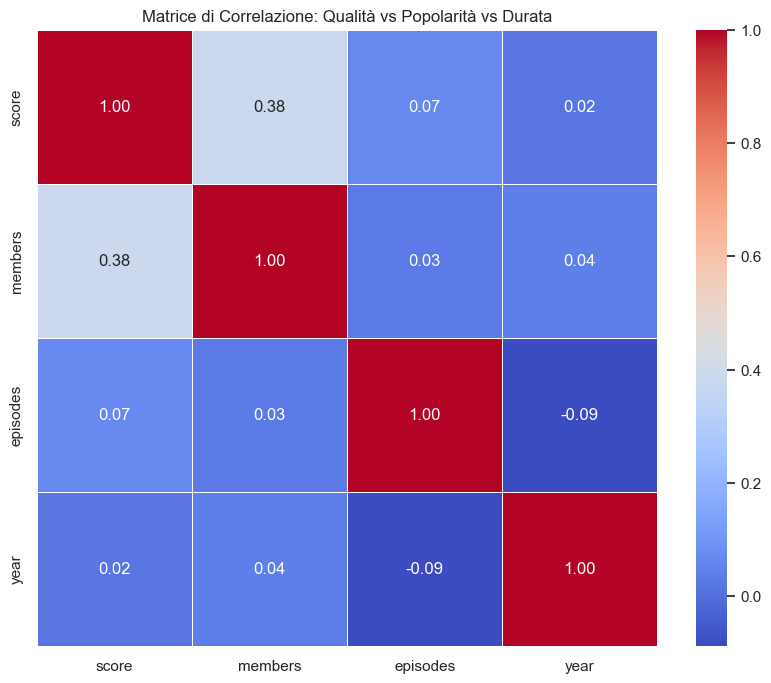

INSIGHT: Notiamo che 'Members' (Popolarità) ha una correlazione positiva con 'Score'.
Questo suggerisce che gli anime più visti tendono ad avere voti più alti (effetto 'Bandwagon' o reale qualità?).


In [12]:
cols_corr = ['score', 'members', 'episodes', 'year']
corr_matrix = df_anime[cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice di Correlazione: Qualità vs Popolarità vs Durata")
plt.show()

print("INSIGHT: Notiamo che 'Members' (Popolarità) ha una correlazione positiva con 'Score'.")
print("Questo suggerisce che gli anime più visti tendono ad avere voti più alti (effetto 'Bandwagon' o reale qualità?).")


---
# 1. Data Engineering: Pulizia Temporale

**Obiettivo:** Preparare la dimensione temporale per l'analisi.

Il dataset originale contiene date in formati misti. In questo passaggio:

**1.**  Estraiamo l'anno dalla colonna `aired` o `start_date`.                                                       
**2.**  Creiamo una colonna pulita `start_year` fondamentale per i grafici temporali.
**3.**  Filtriamo solo le serie TV per evitare il "rumore" di OVA e Special.

## 1.1. L'Evoluzione Storica: Dal Niche al Mainstream

**Domanda:** Come è cambiata la produzione dagli anni '90 a oggi?

L'industria degli anime non è sempre stata il colosso globale che conosciamo oggi.                                   
Il grafico seguente mostra il numero di titoli rilasciati annualmente dal 1960 al 2024.

**Cosa cercare nel grafico:**
* **La Crescita Organica (1960-1990):** Una crescita lenta e costante, dominata dalla TV tradizionale.
* **Il Boom Digitale (2000-2015):** L'esplosione dovuta all'avvento del digitale e dello streaming, che ha abbassato le barriere di produzione e distribuzione.
* **La Stabilizzazione Recente:** Come il mercato si sta assestando dopo il picco.

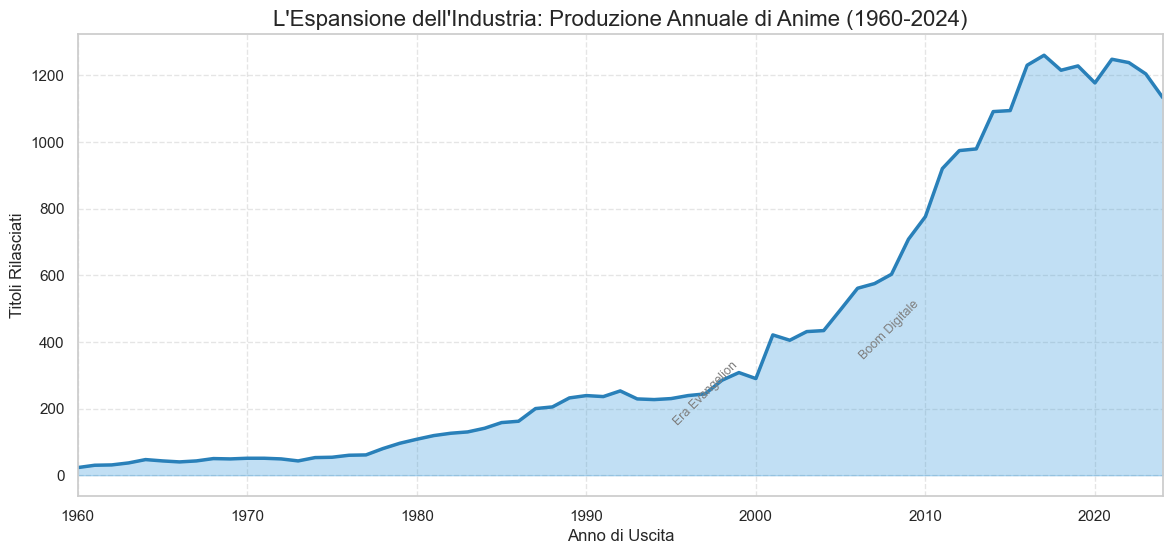

In [13]:
if df_anime is not None:
    df_trend = df_anime[(df_anime['year'] >= 1960) & (df_anime['year'] <= 2024)]
    anime_per_year = df_trend['year'].value_counts().sort_index()


    plt.figure(figsize=(14, 6))
    sns.lineplot(x=anime_per_year.index, y=anime_per_year.values, color='#2980b9', linewidth=2.5)
    plt.fill_between(anime_per_year.index, anime_per_year.values, color='#3498db', alpha=0.3)

    plt.text(1995, 150, 'Era Evangelion', rotation=45, color='gray', fontsize=9)
    plt.text(2006, 350, 'Boom Digitale', rotation=45, color='gray', fontsize=9)

    plt.title("L'Espansione dell'Industria: Produzione Annuale di Anime (1960-2024)", fontsize=16)
    plt.xlabel("Anno di Uscita", fontsize=12)
    plt.ylabel("Titoli Rilasciati", fontsize=12)
    plt.xlim(1960, 2024)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.show()

## 1.2. L'Evoluzione Interattiva (1960-2024)
Per esplorare il "Boom" degli anime, utilizziamo un grafico interattivo **Plotly**.                                  
Passa il mouse sui punti per scoprire i titoli che hanno segnato la storia.
* **Asse X:** Anno di uscita
* **Asse Y:** Voto Medio (Qualità)
* **Dimensione Bolla:** Numero di Fan (Popolarità)

In [14]:
df_clean_years = df_anime[(df_anime['year'] > 1960) & (df_anime['year'] < 2025)].copy()

fig = px.scatter(df_clean_years,
                 x="year",
                 y="score",
                 size="members",
                 color="type",
                 hover_name="title",
                 opacity=0.6,
                 size_max=50,
                 title="Interattivo: 60 Anni di Anime (Dimensione = Popolarità)")

fig.update_layout(xaxis_title="Anno di Pubblicazione", yaxis_title="Score (MyAnimeList)")
fig.show()


---
# 2. Analisi dei Generi: Market Share vs Apprezzamento

Un errore comune è pensare che ciò che viene prodotto di più sia ciò che il pubblico ama di più.
Qui confrontiamo due metriche fondamentali:
1.  **Market Share (Quantità):** Quali generi gli studi decidono di produrre (es. *Comedy, Action*).
2.  **User Score (Qualità):** Come il pubblico valuta effettivamente questi generi.

**Ipotesi:** Ci aspettiamo che i generi "di massa" (come la Commedia) abbiano una qualità media più bassa e variabile rispetto a generi di nicchia o impegnati (come il Drama o il Thriller).

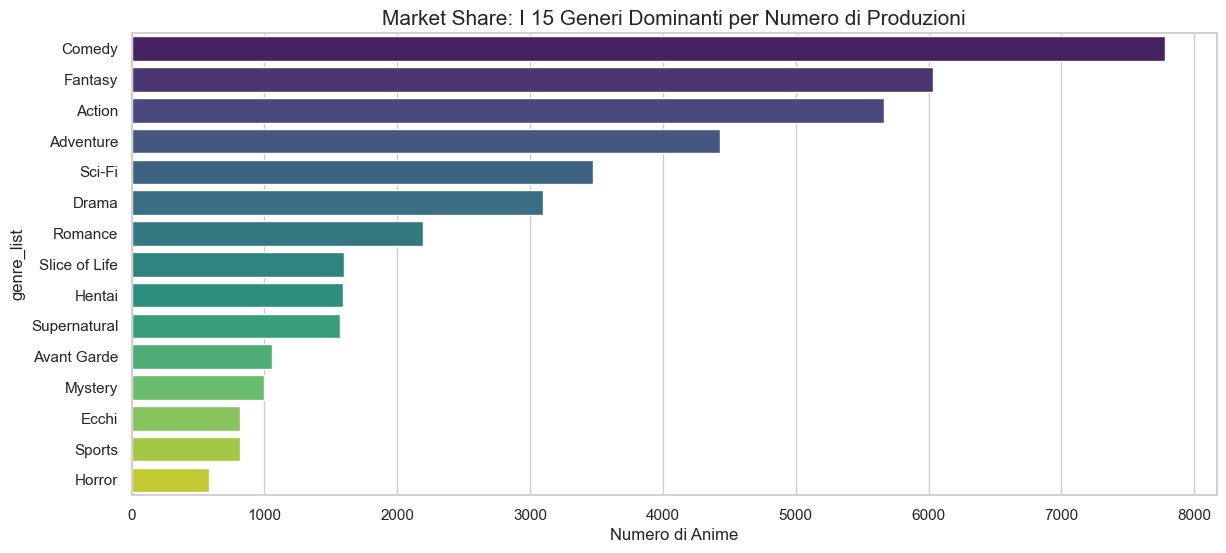

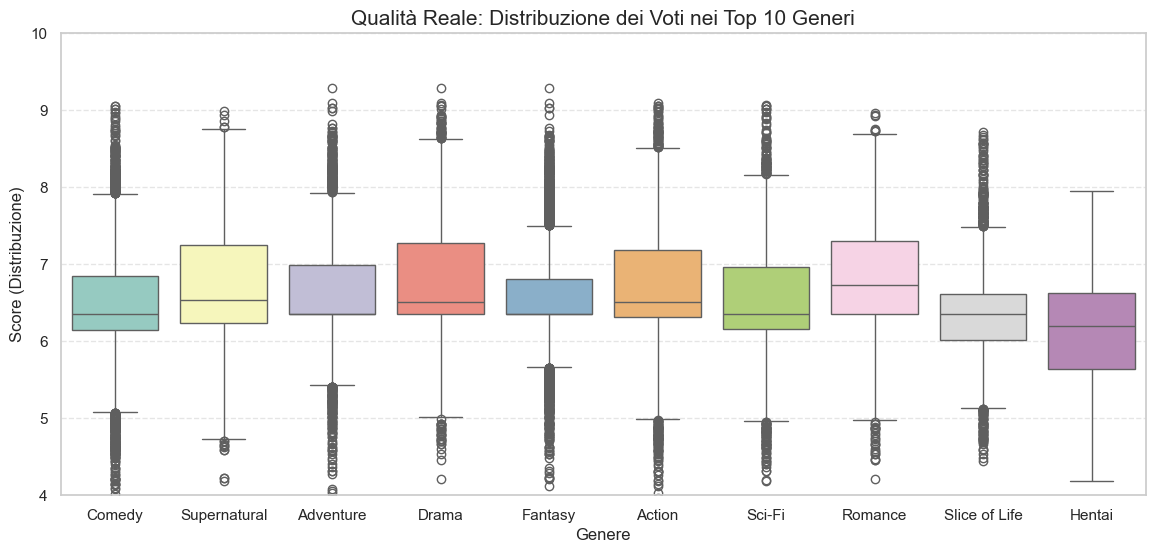

Insight: Nota come generi di massa (es. Comedy) abbiano una varianza enorme, mentre generi di nicchia (es. Drama/Mystery) tendano ad avere medie più alte.


In [15]:
if df_anime is not None:
    sample_genre = df_anime['genre_list'].iloc[0] if 'genre_list' in df_anime.columns else []
    if isinstance(sample_genre, str): 
        df_anime['genre_list'] = df_anime['genres'].fillna('').str.split(', ')

    df_exploded = df_anime.explode('genre_list')
    df_exploded = df_exploded[df_exploded['genre_list'].str.strip() != '']


    
    top_genres_counts = df_exploded['genre_list'].value_counts().head(15)
    
    plt.figure(figsize=(14, 6))
    sns.barplot(x=top_genres_counts.values, y=top_genres_counts.index, hue=top_genres_counts.index, palette='viridis', legend=False)
    plt.title('Market Share: I 15 Generi Dominanti per Numero di Produzioni', fontsize=15)
    plt.xlabel('Numero di Anime')
    plt.show()


    
    top_10_names = top_genres_counts.head(10).index
    df_subset = df_exploded[df_exploded['genre_list'].isin(top_10_names)]

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_subset, x='genre_list', y='score', palette="Set3", hue='genre_list', legend=False)
    
    plt.title('Qualità Reale: Distribuzione dei Voti nei Top 10 Generi', fontsize=15)
    plt.xlabel('Genere')
    plt.ylabel('Score (Distribuzione)')
    plt.ylim(4, 10) 
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()
    
    print("Insight: Nota come generi di massa (es. Comedy) abbiano una varianza enorme, mentre generi di nicchia (es. Drama/Mystery) tendano ad avere medie più alte.")


---
# 3. Profilo Demografico: Chi è l'Otaku Medio?

Per un giornalista è fondamentale capire *chi* sta guardando questi contenuti.
Utilizzando il dataset dei profili utente (`Profiles.csv`), abbiamo tracciato la distribuzione dell'età dell'utenza attiva.

Questo grafico smentisce lo stereotipo che gli anime siano "cartoni per bambini". La curva di densità (KDE) ci mostrerà dove si concentra il "core audience" della piattaforma.

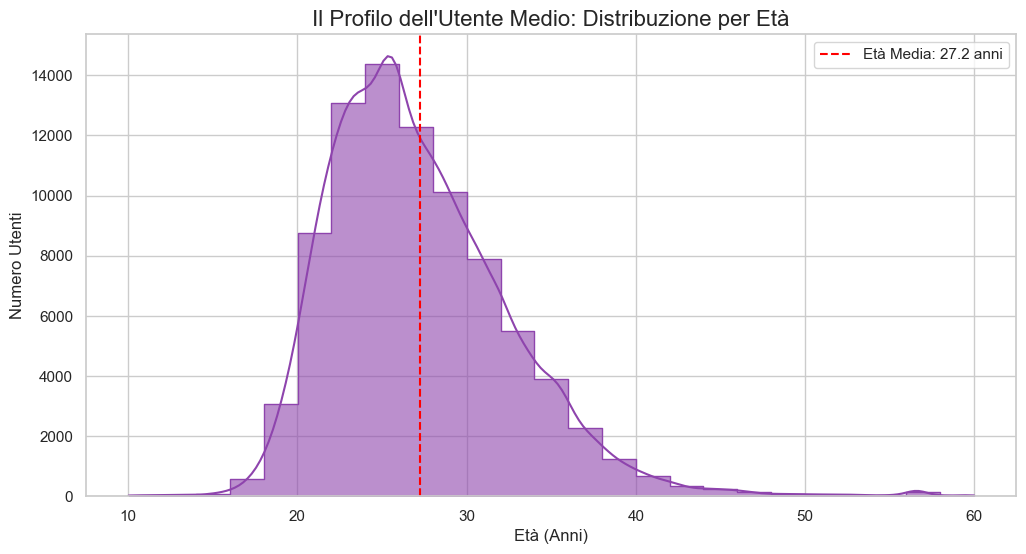

In [16]:
if df_profiles is not None and 'age' in df_profiles.columns:
    valid_ages = df_profiles[(df_profiles['age'] >= 10) & (df_profiles['age'] <= 60)]

    plt.figure(figsize=(12, 6))
    sns.histplot(valid_ages['age'], bins=25, kde=True, color='#8e44ad', element="step", alpha=0.6)
    
    mean_age = valid_ages['age'].mean()
    plt.axvline(mean_age, color='red', linestyle='--', label=f'Età Media: {mean_age:.1f} anni')

    

    plt.title('Il Profilo dell\'Utente Medio: Distribuzione per Età', fontsize=16)
    plt.xlabel('Età (Anni)')
    plt.ylabel('Numero Utenti')
    plt.legend()
    plt.show()


---
# 4. Studio Wars: I Giganti dell'Animazione

**Domanda:** Chi domina il mercato? Quantità industriale o artigianato di lusso?

In questo grafico a dispersione (Scatterplot) posizioniamo ogni Studio di animazione in base a:
* **Asse X (Quantità):** Numero di anime prodotti.
* **Asse Y (Qualità):** Voto medio delle loro opere.

**Chiave di lettura:**
* **Alto-Destra (I Re):** Tanti anime e alta qualità (es. Madhouse, Production I.G).
* **Alto-Sinistra (Boutique):** Pochi anime ma capolavori (es. Ghibli, Kyoto Animation).
* **Basso-Destra (Factory):** Produzione di massa a discapito della qualità.

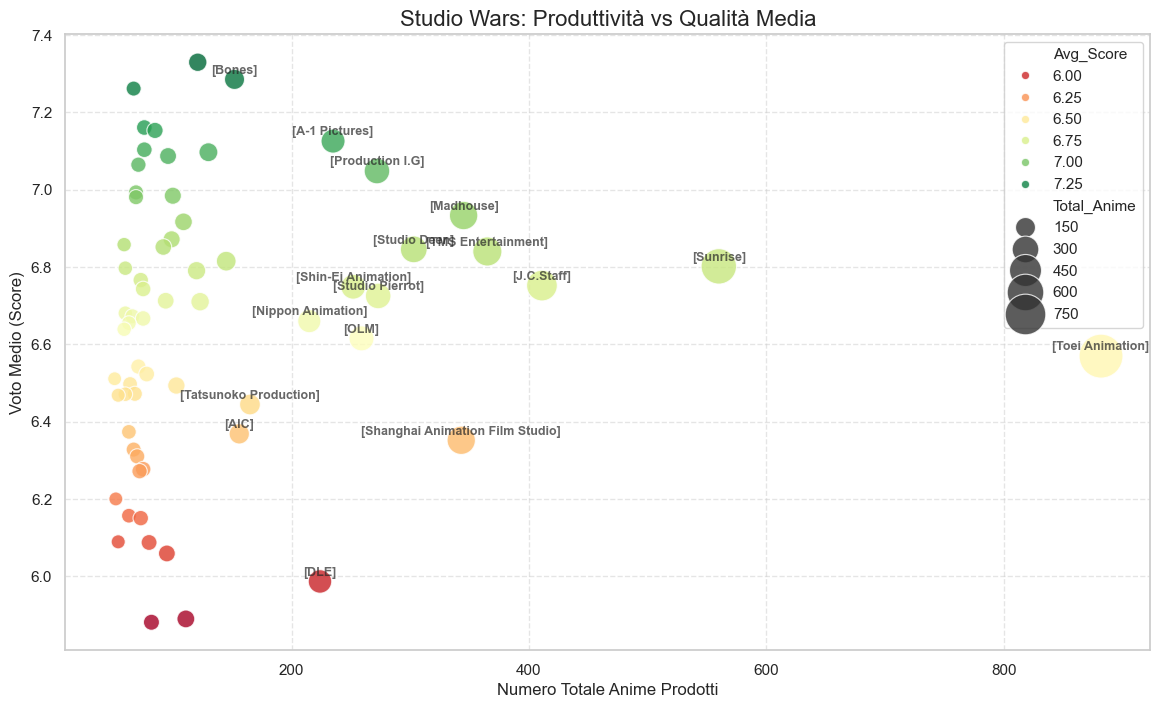

In [17]:
if 'studios' in df_anime.columns:
    df_anime['main_studio'] = df_anime['studios'].astype(str).str.replace(r"[']", "", regex=True).str.split(',').str[0].str.strip()
    
    studio_stats = df_anime.groupby('main_studio').agg(
        Total_Anime=('anime_id', 'count'),
        Avg_Score=('score', 'mean')
    ).reset_index()

    top_studios = studio_stats[
        (studio_stats['Total_Anime'] > 50) & 
        (studio_stats['Total_Anime'] < 3000) & 
        (studio_stats['main_studio'] != '') &
        (studio_stats['main_studio'] != 'None')
    ].sort_values('Avg_Score', ascending=False)

    plt.figure(figsize=(14, 8))
    sns.scatterplot(
        data=top_studios, 
        x='Total_Anime', 
        y='Avg_Score', 
        size='Total_Anime', 
        sizes=(100, 1000),
        hue='Avg_Score', 
        palette='RdYlGn', 
        alpha=0.8
    )

    for i in range(top_studios.shape[0]):
        row = top_studios.iloc[i]
        if row['Total_Anime'] > 150 or row['Avg_Score'] > 7.4:
            plt.text(row['Total_Anime'], row['Avg_Score']+0.015, row['main_studio'], 
                     fontsize=9, ha='center', fontweight='bold', alpha=0.7)

    plt.title('Studio Wars: Produttività vs Qualità Media', fontsize=16)
    plt.xlabel('Numero Totale Anime Prodotti', fontsize=12)
    plt.ylabel('Voto Medio (Score)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

## 4.1. Studio Wars: Quantità vs Qualità (Il "Complex Example")

In questa sezione applichiamo una metodologia avanzata per valutare gli studi di animazione.
Invece di limitarci a contare *quanti* anime produce uno studio (una metrica puramente quantitativa), calcoliamo il loro **Tasso di Successo** (Success Rate).

**Metodologia:**
Utilizziamo il pattern *Filter -> Group -> Merge -> Percentage*:
1.  **Group:** Calcoliamo il volume totale di produzione per ogni studio.
2.  **Filter:** Isoliamo solo le opere di "Alta Qualità" (Score > 7.5).
3.  **Merge:** Uniamo i due dataset per confrontare le produzioni totali con i successi.
4.  **Percentage:** Calcoliamo la % di capolavori sul totale.

Questo ci permette di distinguere tra "Fabbriche di Anime" (tanta quantità, qualità variabile) e "Boutique Artigianali" (pochi anime, ma tutti curati).

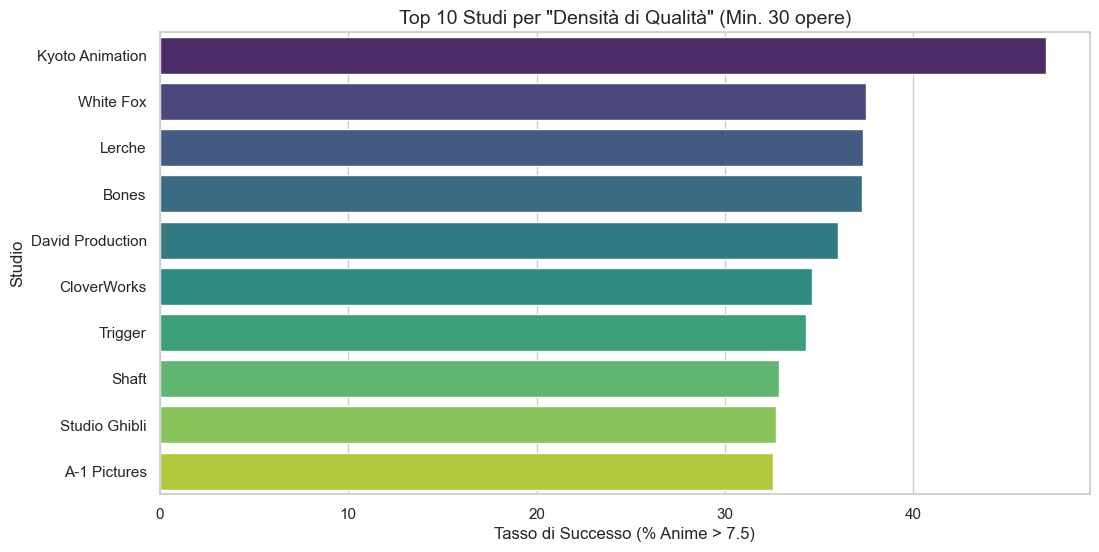

Dettaglio Top 5 Studi:
        primary_studio  success_rate  total_count  quality_count
482    Kyoto Animation     47.014925          134           63.0
1087         White Fox     37.500000           48           18.0
498             Lerche     37.313433           67           25.0
135              Bones     37.267081          161           60.0
225   David Production     36.000000           50           18.0


In [18]:
possible_names = ['studio', 'studios', 'producer', 'producers', 'production']
col_studio = next((col for col in possible_names if col in df_anime.columns), None)

if col_studio:
    df_studios = df_anime.dropna(subset=[col_studio, 'score']).copy()

    def clean_studio_name(val):
        s = str(val)
        s = s.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
        return s.split(',')[0].strip()

    df_studios['primary_studio'] = df_studios[col_studio].apply(clean_studio_name)

    total_works = df_studios.groupby('primary_studio').size().reset_index(name='total_count')

    high_quality_threshold = 7.5
    high_quality_df = df_studios[df_studios['score'] > high_quality_threshold]
    quality_works = high_quality_df.groupby('primary_studio').size().reset_index(name='quality_count')
    studio_stats = pd.merge(total_works, quality_works, on='primary_studio', how='left')
    studio_stats['quality_count'] = studio_stats['quality_count'].fillna(0)
    studio_stats['success_rate'] = (studio_stats['quality_count'] / studio_stats['total_count']) * 100


    
    min_production = 30
    top_studios = studio_stats[studio_stats['total_count'] >= min_production].sort_values('success_rate', ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_studios, x='success_rate', y='primary_studio', palette='viridis')
    plt.title(f'Top 10 Studi per "Densità di Qualità" (Min. {min_production} opere)', fontsize=14)
    plt.xlabel('Tasso di Successo (% Anime > 7.5)', fontsize=12)
    plt.ylabel('Studio', fontsize=12)
    plt.show()

    print("Dettaglio Top 5 Studi:")
    print(top_studios[['primary_studio', 'success_rate', 'total_count', 'quality_count']].head(5))


---
# 5. Insight sul "Fattore Noia": Analisi del Drop Rate

L'ultimo grafico di questo notebook esplora la relazione critica tra la lunghezza dell'opera (o la densità di episodi) e la tendenza degli utenti ad abbandonare la visione, definendo il cosiddetto "Fattore Noia".

1.  **Soglia di Attenzione:** I dati mostrano un punto di flesso evidente; superato un certo numero di episodi, il tasso di abbandono (*Dropped*) aumenta, indicando una fatica fisiologica dello spettatore.
2.  **Ritmo vs. Fedeltà:** Le opere che riescono a mantenere basso il "Fattore Noia" nonostante una lunga durata sono eccezioni rare, suggerendo che il ritmo narrativo è la chiave per la *retention* a lungo termine.
3.  **Correlazione con il Voto:** Un alto indice di noia (molti abbandoni) tende a correlarsi negativamente con il punteggio finale, confermando che l'incapacità di mantenere l'ingaggio penalizza la percezione complessiva dell'opera.


Caricamento stats.pkl...


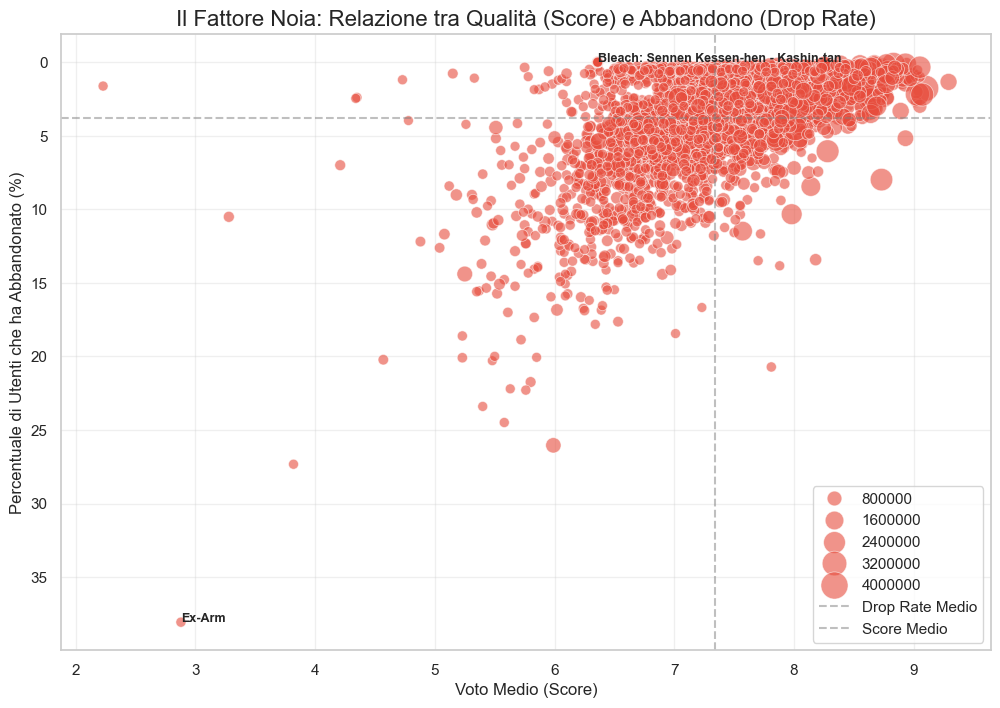

Insight: In alto a destra troviamo i 'Page Turners' (belli e avvincenti).
In basso a destra i 'Mattoni' (belli ma lenti/pesanti).


In [19]:
df_stats = load_from_cache('stats.pkl')

if df_stats is not None and df_anime is not None:
    engagement_df = pd.merge(df_anime[['anime_id', 'title', 'score', 'members']], 
                             df_stats[['anime_id', 'drop_rate']], 
                             on='anime_id', 
                             how='inner')
    
    popular_engagement = engagement_df[engagement_df['members'] > 50000]

    plt.figure(figsize=(12, 8))
    
    sns.scatterplot(
        data=popular_engagement,
        x='score',
        y='drop_rate',
        size='members',
        sizes=(50, 400),
        alpha=0.6,
        color='#e74c3c'
    )
    
    plt.axhline(popular_engagement['drop_rate'].mean(), color='grey', linestyle='--', alpha=0.5, label='Drop Rate Medio')
    plt.axvline(popular_engagement['score'].mean(), color='grey', linestyle='--', alpha=0.5, label='Score Medio')

    highest_drop = popular_engagement.loc[popular_engagement['drop_rate'].idxmax()]
    plt.text(highest_drop['score'], highest_drop['drop_rate'], highest_drop['title'], fontsize=9, fontweight='bold')

    lowest_drop = popular_engagement.loc[popular_engagement['drop_rate'].idxmin()]
    plt.text(lowest_drop['score'], lowest_drop['drop_rate'], lowest_drop['title'], fontsize=9, fontweight='bold')

    plt.title('Il Fattore Noia: Relazione tra Qualità (Score) e Abbandono (Drop Rate)', fontsize=16)
    plt.xlabel('Voto Medio (Score)')
    plt.ylabel('Percentuale di Utenti che ha Abbandonato (%)')
    plt.gca().invert_yaxis()
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print("Insight: In alto a destra troviamo i 'Page Turners' (belli e avvincenti).")
    print("In basso a destra i 'Mattoni' (belli ma lenti/pesanti).")


---
# 6. L'Era della "Shrinkflation" Mediatica: Episodi e Soglia dell'Attenzione

**Obiettivo:** Indagare la correlazione tra i cambiamenti nei modelli produttivi e la riduzione della soglia di attenzione del pubblico moderno.

Il grafico seguente visualizza un fenomeno che potremmo definire **"Shrinkflation degli Episodi"**: la tendenza dell'industria a ridurre drasticamente il numero di episodi per stagione, passando dalle lunghe epopee continuative degli anni '90 (spesso 26+ o 50+ episodi) al formato standardizzato odierno del "single cour" (11-13 episodi).

**Chiavi di lettura dell' analisi:**

1.  **Adattamento alla "Attention Economy":** La riduzione della durata media risponde alla necessità di catturare un pubblico con un *attention span* sempre più frammentato, che predilige archi narrativi densi e rapidi rispetto a trame diluite.
2.  **Smoothing dei Dati:** Utilizziamo una **Media Mobile a 3 anni (Rolling Average)** per filtrare il rumore statistico annuale ed evidenziare chiaramente la discesa strutturale della "lunghezza media" di una serie TV.
3.  **Il Nuovo Standard:** Identifichiamo il punto di svolta in cui la linea di tendenza si stabilizza attorno alla soglia psicologica dei **12 episodi**, divenuta ormai l'unità di misura industriale per minimizzare il rischio finanziario.

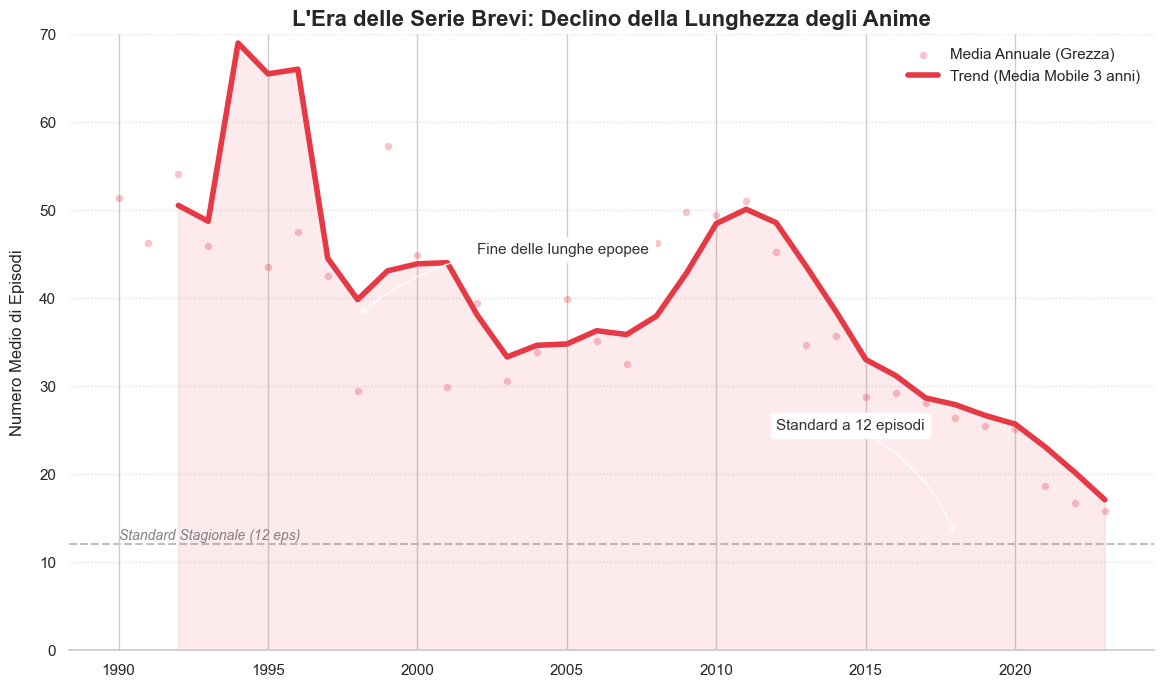

In [20]:
df_anime['start_year'] = pd.to_numeric(df_anime['year'], errors='coerce')
df_anime['start_date'] = pd.to_datetime(df_anime['start_date'], errors='coerce')
df_anime['start_year'] = df_anime['start_year'].fillna(df_anime['start_date'].dt.year)

df_graph = df_anime[
    (df_anime['start_year'] >= 1990) & 
    (df_anime['start_year'] <= 2023) & 
    (df_anime['type'] == 'TV')
].copy()

yearly_data = df_graph.groupby('start_year')['episodes'].mean().reset_index()
yearly_data['rolling_avg'] = yearly_data['episodes'].rolling(window=3).mean()



plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

plt.axhline(y=12, color='gray', linestyle='--', alpha=0.5, linewidth=1.5, zorder=0)
plt.text(1990, 12.5, "Standard Stagionale (12 eps)", color='gray', fontsize=10, style='italic')

sns.scatterplot(data=yearly_data, x='start_year', y='episodes', 
                color='#E63946', alpha=0.3, s=30, label='Media Annuale (Grezza)')

sns.lineplot(data=yearly_data, x='start_year', y='rolling_avg', 
             color='#E63946', linewidth=4, label='Trend (Media Mobile 3 anni)')

plt.fill_between(yearly_data['start_year'], yearly_data['rolling_avg'], 0, 
                 color='#E63946', alpha=0.1)

plt.title("L'Era delle Serie Brevi: Declino della Lunghezza degli Anime", fontsize=16, weight='bold')
plt.ylabel("Numero Medio di Episodi", fontsize=12, labelpad=10)
plt.xlabel("", fontsize=12)

plt.annotate('Fine delle lunghe epopee', 
             xy=(1998, 38), xytext=(2002, 45),
             arrowprops=dict(facecolor='#333333', arrowstyle="->", connectionstyle="arc3,rad=.2"),
             fontsize=11, color='#333333', backgroundcolor='white')

plt.annotate('Standard a 12 episodi', 
             xy=(2018, 13), xytext=(2012, 25),
             arrowprops=dict(facecolor='#333333', arrowstyle="->", connectionstyle="arc3,rad=-.2"),
             fontsize=11, color='#333333', backgroundcolor='white')

sns.despine(left=True, bottom=False)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.ylim(0, 70)
plt.legend(loc='upper right', frameon=False)

plt.show()


---
# 7. Conclusioni e Insight per il Report

Dall'analisi dei dati emergono tre trend chiari per la stesura del report finale:

1.  **Saturazione del Mercato:** La produzione è esplosa post-2000, portando a una quantità enorme di titoli che competono per l'attenzione.
2.  **Qualità di Nicchia:** Mentre il mercato è inondato di *Comedy* e *Action*, i voti più alti si concentrano spesso in generi più maturi o specifici (*Drama, Thriller*), suggerendo che il pubblico premia la profondità narrativa.
3.  **Maturità del Pubblico:** L'età media degli utenti conferma che l'anime è un medium trasversale, non limitato all'infanzia, con una forte base di utenza giovane-adulta (20-30 anni).
4.  **Gerarchia degli Studi:** I dati confermano che pochi studi ("Boutique") mantengono una media qualitativa altissima, mentre i grandi colossi faticano a mantenere la qualità su grandi volumi.
5.  **Il formato si è ristretto:** L'era delle serie infinite è finita. Lo standard oggi è il "cour" da 12 episodi, meno rischioso per i produttori.

---
*Analisi generata via Python/Pandas - Progetto HCI 2025*